In [1]:
%reset -f

In [2]:
import sys
print(sys.executable)

/oak/stanford/groups/engreitz/Users/tri/envs/sc-dl/bin/python


In [ ]:
import scanpy as sc
import muon as mu
import pandas as pd
import numpy as np
import os


/oak/stanford/groups/engreitz/Users/tri/envs/sc-dl/lib/python3.11/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [6]:
core_path = "/oak/stanford/groups/engreitz/Users/opushkar/cc_perturb/2.preprocessing_tonys_pipeline"
adata_int = sc.read_h5ad(
    os.path.join(
        core_path,
        "3.integrated_days",
        "3.all_days_concat_all_genes_sceptre_guides.h5ad"
    )
)

In [7]:
adata_int

AnnData object with n_obs × n_vars = 121616 × 17538
    obs: 'guides_per_cell', 'guide_umi_counts', 'pct_counts_ribo', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'pool', 'sample_id', 'round1', 'well', 'biological_sample', 'plate', 'bci', 'stype', 'day', 'cell_pool', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'S_score', 'G2M_score', 'phase', 'outlier', 'size_factors', 'diff_day', 'leiden_res_0.0', 'leiden_res_0.1', 'leiden_res_0.2', 'leiden_res_0.3', 'leiden_res_0.4', 'leiden_res_0.5', 'leiden_res_0.6', 'leiden_res_0.7', 'leiden_res_0.8', 'leiden_res_0.9', 'leiden_res_1.0', 'leiden_res_1.1', 'leiden_res_1.2'
    var: 'ensembl_id', 'gene_symbol'
    uns: 'guide_names', 'leiden_res_0.0', 'leiden_res_0.1', 'leiden_res_0.2', 'leiden_res_0.3', 'leiden_res_0.3_colo

In [9]:
import scanpy as sc

# 1. Normalize and Log-transform (if starting from raw counts)
# sc.pp.normalize_total(adata, target_sum=1e4)
# sc.pp.log1p(adata)

# 2. Identify Highly Variable Genes (essential for clean clusters)
sc.pp.highly_variable_genes(adata_int, min_mean=0.0125, max_mean=3, min_disp=0.5)

# 3. Filter to HVGs and Scale
# We store the full data in .raw before filtering
adata_int.raw = adata_int
adata_int = adata_int[:, adata_int.var.highly_variable].copy()
sc.pp.scale(adata_int, max_value=10)

/oak/stanford/groups/engreitz/Users/tri/envs/sc-dl/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [11]:
sc.tl.pca(adata_int, svd_solver='arpack')

# Optional: Check the elbow plot to see if 50 PCs is enough
# sc.pl.pca_variance_ratio(adata, log=True)
# 1. Compute Neighbors
# Increase n_neighbors (e.g., 20 or 30) for more "global" structure
sc.pp.neighbors(adata_int, n_neighbors=15, n_pcs=40)

# 2. Compute UMAP
# To spread clusters out more, increase 'min_dist' (default is 0.5)
sc.tl.umap(adata_int, min_dist=0.5, spread=1.0)

In [26]:
# Re-run Leiden at your preferred resolution
sc.tl.leiden(adata_int, resolution=0.5, key_added='leiden_new')

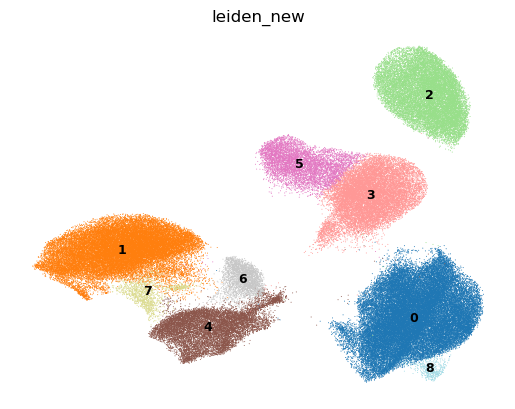

In [63]:
sc.pl.umap(adata_int, 
           color='leiden_new', 
           legend_loc='on data', 
           legend_fontsize=9, 
           #add_outline=True, 
           frameon=False, 
           size=2)

In [78]:
adata_int

AnnData object with n_obs × n_vars = 121616 × 4165
    obs: 'guides_per_cell', 'guide_umi_counts', 'pct_counts_ribo', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'pool', 'sample_id', 'round1', 'well', 'biological_sample', 'plate', 'bci', 'stype', 'day', 'cell_pool', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'S_score', 'G2M_score', 'phase', 'outlier', 'size_factors', 'diff_day', 'leiden_res_0.0', 'leiden_res_0.1', 'leiden_res_0.2', 'leiden_res_0.3', 'leiden_res_0.4', 'leiden_res_0.5', 'leiden_res_0.6', 'leiden_res_0.7', 'leiden_res_0.8', 'leiden_res_0.9', 'leiden_res_1.0', 'leiden_res_1.1', 'leiden_res_1.2', 'leiden_new', 'cell_type', 'Program 0', 'Program 1', 'Program 2', 'Program 3', 'Program 4', 'Program 5', 'Program 6', 'Program 7', 'Program 8', 'Program 

In [61]:
cluster_mapping = {
    '0': 'iPSC',
    '1': 'artEC',
    '2': 'PrimStreak', 
    '3': 'Lat-Meso',
    '4': 'Fibro-Mesen',
    '5': 'Pre-EC',
    '6': 'Neu-Mesen',
    '7': 'ECM-EC',
    '8': 'Cyc-iPSC',
}

# 2. Map the labels to a new column in adata.obs
# Replace 'leiden_res_0.8' with whatever your current clustering column is named
adata_int.obs['cell_type'] = adata_int.obs['leiden_new'].astype(str).map(cluster_mapping)

# Convert the new column to a categorical type (important for Scanpy plotting colors)
adata_int.obs['cell_type'] = adata_int.obs['cell_type'].astype('category')

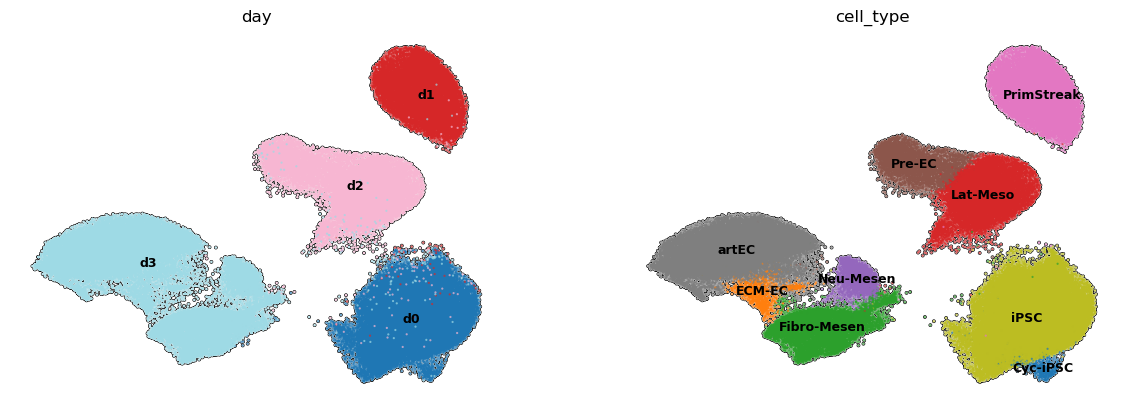

In [62]:
sc.pl.umap(adata_int, 
           color=['day','cell_type'], 
           legend_loc='on data', 
           legend_fontsize=9, 
           add_outline=True, 
           frameon=False,
           #scale_factor=5,
           cmap="YlGnBu",vmin=0, vmax=0.4,
           ncols=2,
           size=10
           )

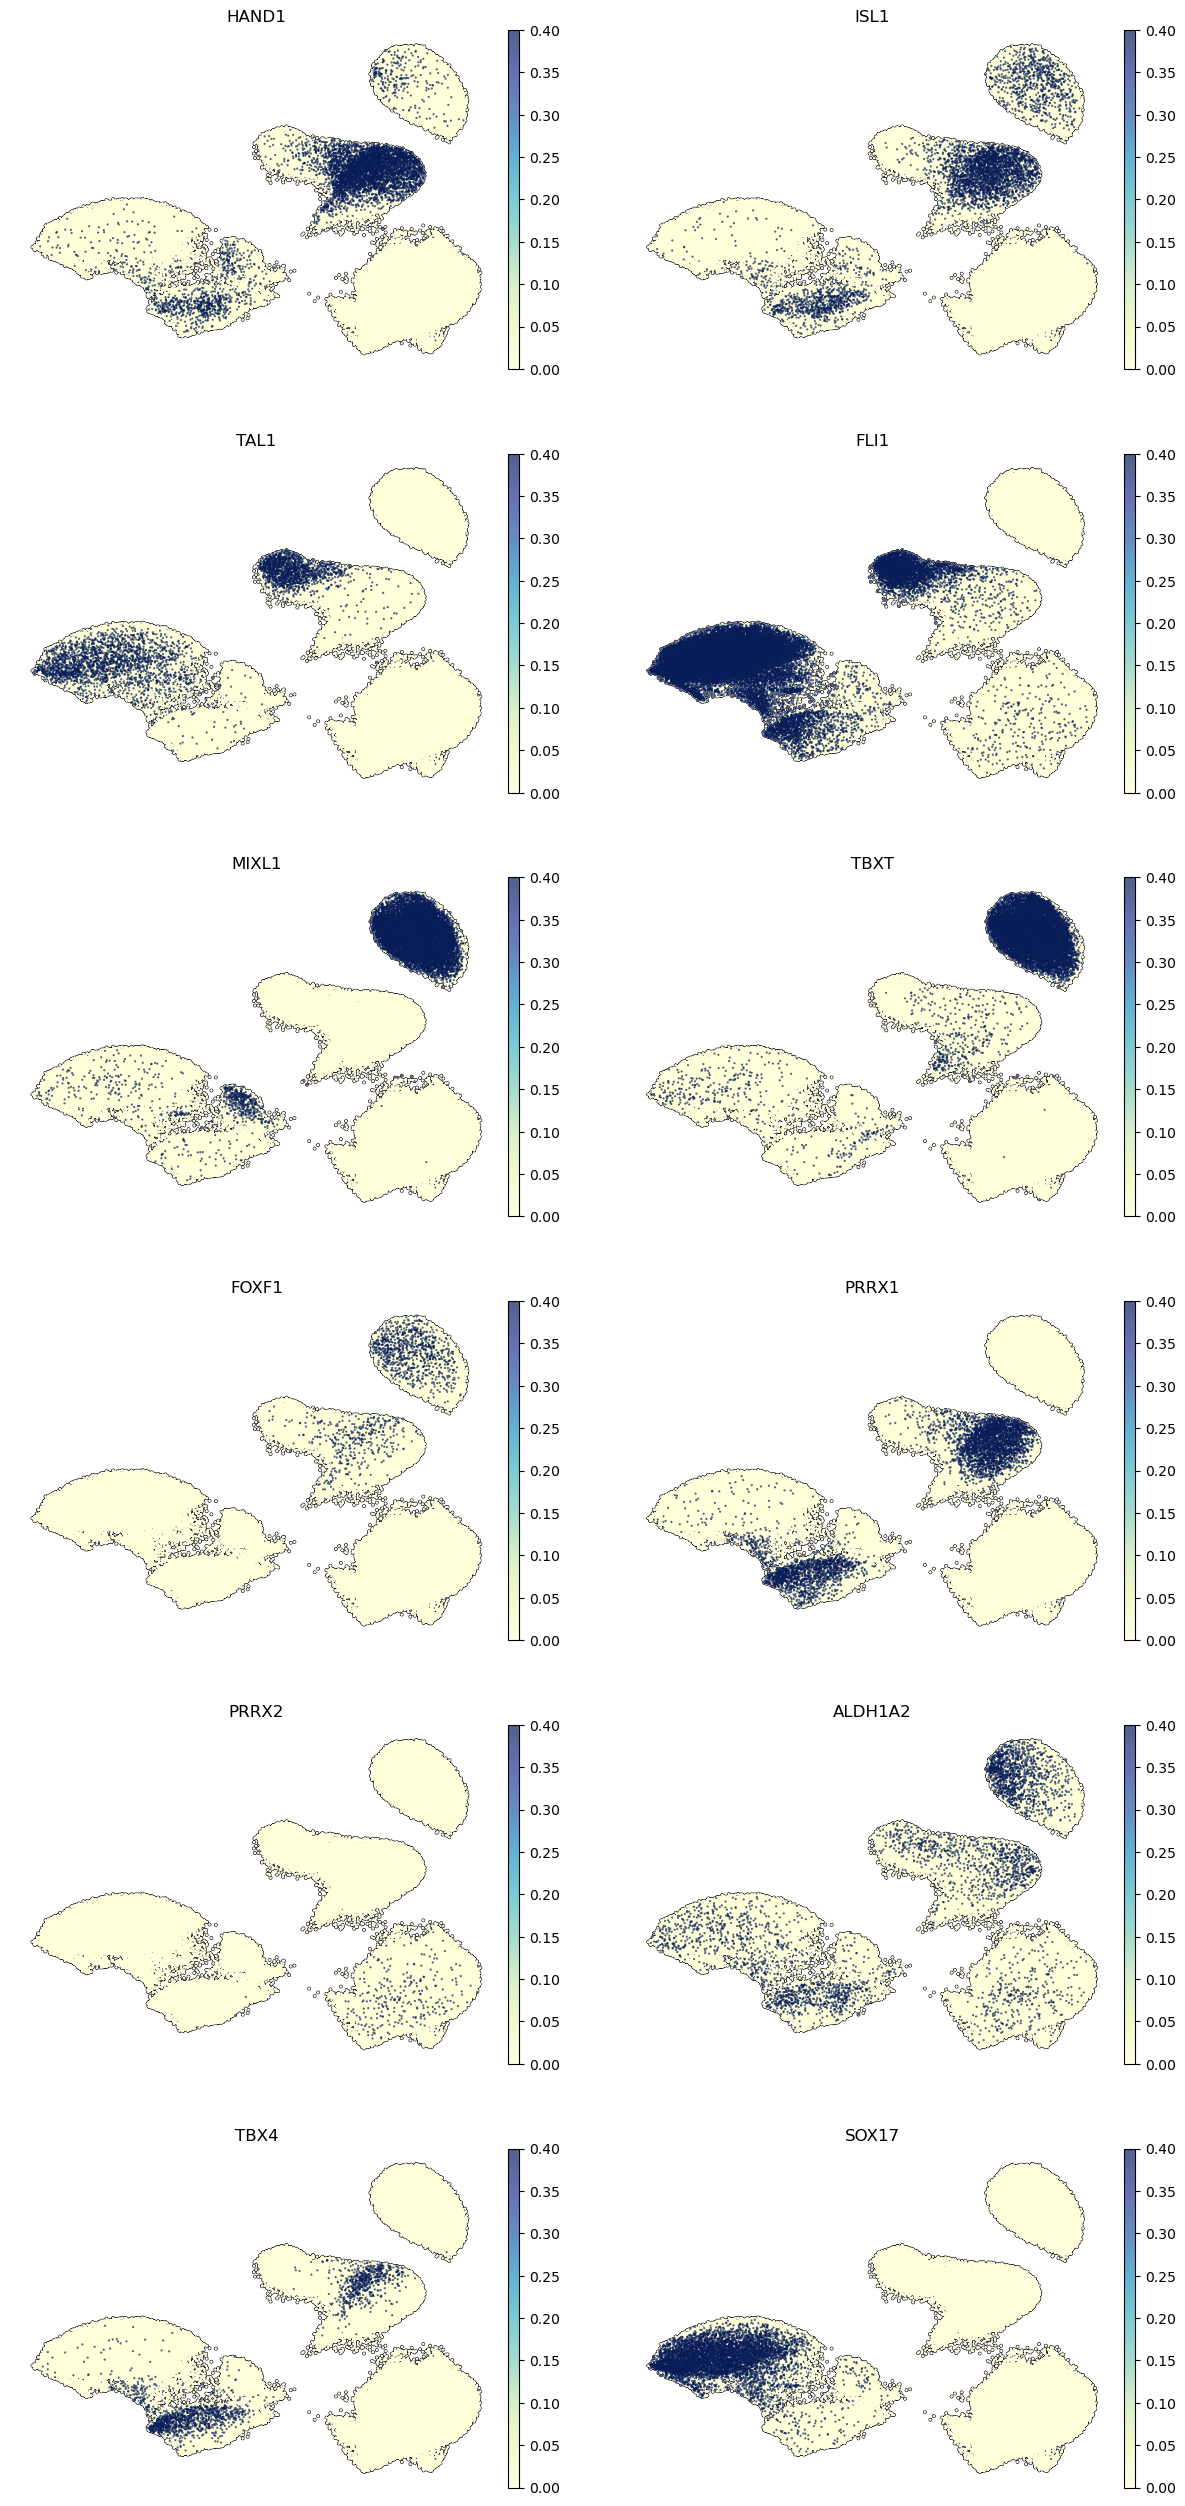

In [57]:
sc.pl.umap(adata_int, 
           color=['HAND1','ISL1','TAL1','FLI1','MIXL1','TBXT','FOXF1', 'PRRX1', 'PRRX2', 'ALDH1A2', 'TBX4','SOX17'], 
           legend_loc='on data', 
           legend_fontsize=9, 
           add_outline=True, 
           frameon=False,
           #scale_factor=5,
           cmap="YlGnBu",vmin=0, vmax=0.4,
           ncols=2,
           size=10)

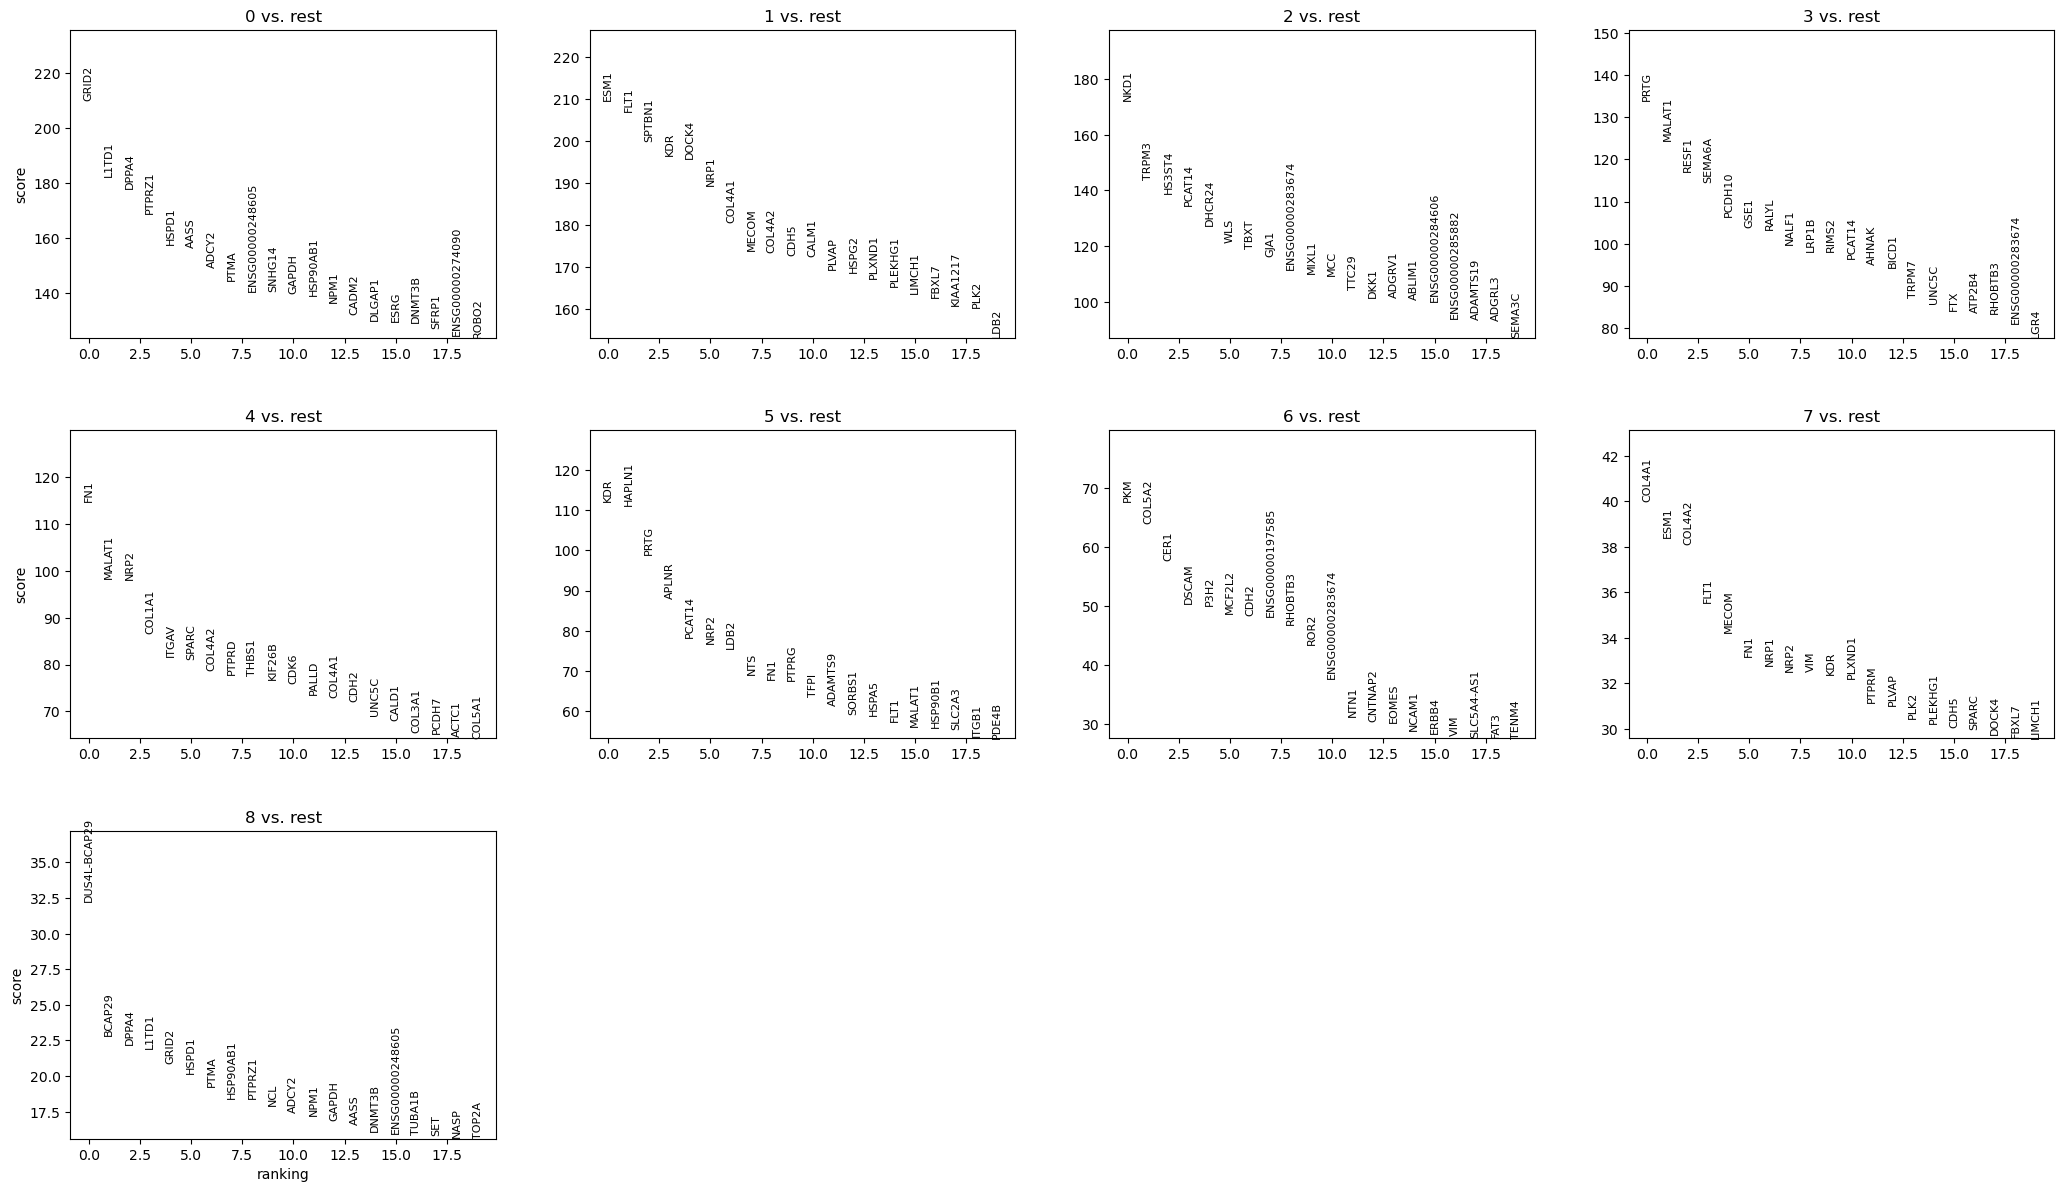

In [30]:

sc.tl.rank_genes_groups(adata_int, 'leiden_new', method='wilcoxon', key_added='rank_genes_0.8')

# Visualize the top 20 genes per cluster in a grid
sc.pl.rank_genes_groups(adata_int, n_genes=20, sharey=False, key='rank_genes_0.8')

In [31]:
import pandas as pd

# Get top 50 markers for all clusters
result_df = sc.get.rank_genes_groups_df(adata_int, group=None, key='rank_genes_0.8')

# Filter for genes with a high logfoldchange and low p-value
markers = result_df[(result_df['pvals_adj'] < 0.05) & (result_df['logfoldchanges'] > 1.0)]

# Show top 5 genes for Cluster 0
print(markers[markers['group'] == '0'].head(5))

  group   names      scores  logfoldchanges  pvals  pvals_adj
0     0   GRID2  209.719818        4.656668    0.0        0.0
1     0   L1TD1  182.366852        3.582042    0.0        0.0
2     0   DPPA4  178.001617        3.376412    0.0        0.0
3     0  PTPRZ1  168.776962        3.302650    0.0        0.0
4     0   HSPD1  157.732727        2.367855    0.0        0.0


In [35]:
import pandas as pd

# Extract the gene names from the uns dictionary
# Note: Ensure the key matches what you set in 'key_added' during the rank_genes_groups step
top_genes_wide = pd.DataFrame(adata_int.uns['rank_genes_0.8']['names']).head(20)

# View the table
display(top_genes_wide)

,0,1,2,3,4,5,6,7,8
0,GRID2,ESM1,NKD1,PRTG,FN1,KDR,PKM,COL4A1,DUS4L-BCAP29
1,L1TD1,FLT1,TRPM3,MALAT1,MALAT1,HAPLN1,COL5A2,ESM1,BCAP29
2,DPPA4,SPTBN1,HS3ST4,RESF1,NRP2,PRTG,CER1,COL4A2,DPPA4
3,PTPRZ1,KDR,PCAT14,SEMA6A,COL1A1,APLNR,DSCAM,FLT1,L1TD1
4,HSPD1,DOCK4,DHCR24,PCDH10,ITGAV,PCAT14,P3H2,MECOM,GRID2
5,AASS,NRP1,WLS,GSE1,SPARC,NRP2,MCF2L2,FN1,HSPD1
6,ADCY2,COL4A1,TBXT,RALYL,COL4A2,LDB2,CDH2,NRP1,PTMA
7,PTMA,MECOM,GJA1,NALF1,PTPRD,NTS,ENSG00000197585,NRP2,HSP90AB1
8,ENSG00000248605,COL4A2,ENSG00000283674,LRP1B,THBS1,FN1,RHOBTB3,VIM,PTPRZ1
9,SNHG14,CDH5,MIXL1,RIMS2,KIF26B,PTPRG,ROR2,KDR,NCL


IMPORT cNMF MATRIX

In [65]:
#1. Define the file path
cnmf_file = "/oak/stanford/groups/engreitz/Users/ymo/IGVF_ccperturbseq/Result/030526_100k_cells_100iter_allHVG_torch_halsvar_batch_e7_50/030526_100k_cells_100iter_allHVG_torch_halsvar_batch_e7_50.usages.k_50.dt_0_2.consensus.txt"

# 2. Read the dataframe
usage_df = pd.read_csv(cnmf_file, sep='\t', index_col=0)

# 3. Align with adata
# This ensures every cell in adata gets its corresponding row from the file.
# Cells in adata but missing from the file will be filled with 0 
usage_aligned = usage_df.reindex(adata_int.obs_names).fillna(0)

# 4. Save to obsm
adata_int.obsm["cnmf_usage"] = usage_aligned

# 5. Validation
print(f"Loaded usage matrix shape: {adata_int.obsm['cnmf_usage'].shape}")
print(f"Overlap check: {usage_df.index.intersection(adata_int.obs_names).shape[0]} cells matched.")

Loaded usage matrix shape: (121616, 50)
Overlap check: 121616 cells matched.


In [66]:
adata_int.obsm["cnmf_usage"]

,1,2,3,4,5,6,7,8,9,10,...,41,42,43,44,45,46,47,48,49,50
barcode,,,,,,,,,,,,,,,,,,,,,
CCTAATCCAACAACCATCTATTAC_2,0.062538,0.027402,0.012862,0.000000,0.050164,0.127009,0.126219,0.086548,0.004646,0.039850,...,0.000000,0.014634,0.000000,0.000452,0.018801,0.004714,0.000000,0.000000,0.0,0.001114
GGTGCGAACCTCCTGAATCCGCGA_2,0.000000,0.019443,0.003818,0.012402,0.030527,0.123209,0.065145,0.046808,0.028964,0.000000,...,0.002084,0.000000,0.000143,0.005316,0.000609,0.006756,0.000000,0.000000,0.0,0.000000
AACTCACCATCATTCCCTGTCCCG_1,0.047637,0.002082,0.000000,0.000000,0.098233,0.006417,0.069543,0.088016,0.049213,0.000000,...,0.000000,0.001022,0.000000,0.000000,0.000000,0.000000,0.000000,0.009507,0.0,0.000000
TTCACGCACACTTCGAATTCATGG_2,0.076358,0.091694,0.019964,0.000000,0.000000,0.000000,0.550251,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.006451,0.000000,0.143893,0.0,0.000000
GTCTGTCAGAGCTGAACCGTTCTA_3,0.021434,0.028805,0.000000,0.022261,0.090041,0.038934,0.155332,0.067275,0.000000,0.023845,...,0.003669,0.021365,0.000062,0.003521,0.000000,0.000006,0.000000,0.000513,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AATCCGTCTCTTCACAGTTACGTA_1,0.043265,0.005368,0.187492,0.109529,0.051960,0.000149,0.000000,0.000000,0.251016,0.013628,...,0.000000,0.033623,0.009541,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
ATCATTCCCGACACACTCACTTTA_2,0.058216,0.067988,0.315200,0.110118,0.000000,0.042405,0.000000,0.000000,0.070178,0.022789,...,0.002244,0.000000,0.000000,0.000000,0.001165,0.000000,0.000564,0.000000,0.0,0.000000
AACAACCAACACAGAAGACCTTTC_1,0.033473,0.029578,0.094773,0.319834,0.080901,0.008600,0.000000,0.012197,0.056045,0.025384,...,0.000000,0.000000,0.001856,0.004313,0.000000,0.000000,0.000000,0.004243,0.0,0.000000


In [69]:
# Rename columns to program_0, program_1, ..., program_49
adata_int.obsm["cnmf_usage"].columns = [f"Program {i}" for i in range(adata_int.obsm["cnmf_usage"].shape[1])]

# Verify the changes
print(adata_int.obsm["cnmf_usage"].head())

                            Program 0  Program 1  Program 2  Program 3  \
barcode                                                                  
CCTAATCCAACAACCATCTATTAC_2   0.062538   0.027402   0.012862   0.000000   
GGTGCGAACCTCCTGAATCCGCGA_2   0.000000   0.019443   0.003818   0.012402   
AACTCACCATCATTCCCTGTCCCG_1   0.047637   0.002082   0.000000   0.000000   
TTCACGCACACTTCGAATTCATGG_2   0.076358   0.091694   0.019964   0.000000   
GTCTGTCAGAGCTGAACCGTTCTA_3   0.021434   0.028805   0.000000   0.022261   

                            Program 4  Program 5  Program 6  Program 7  \
barcode                                                                  
CCTAATCCAACAACCATCTATTAC_2   0.050164   0.127009   0.126219   0.086548   
GGTGCGAACCTCCTGAATCCGCGA_2   0.030527   0.123209   0.065145   0.046808   
AACTCACCATCATTCCCTGTCCCG_1   0.098233   0.006417   0.069543   0.088016   
TTCACGCACACTTCGAATTCATGG_2   0.000000   0.000000   0.550251   0.000000   
GTCTGTCAGAGCTGAACCGTTCTA_3   0.090041

In [70]:
import scanpy as sc

# 1. Loop through all the 'program_X' columns and add them to .obs
for prog in adata_int.obsm["cnmf_usage"].columns:
    # Using .values ensures we bypass any potential index mismatch issues
    adata_int.obs[prog] = adata_int.obsm["cnmf_usage"][prog].values

# Verify they were added
print(adata_int.obs.columns[-5:]) # Look at the last 5 columns added

Index(['Program 45', 'Program 46', 'Program 47', 'Program 48', 'Program 49'], dtype='object')


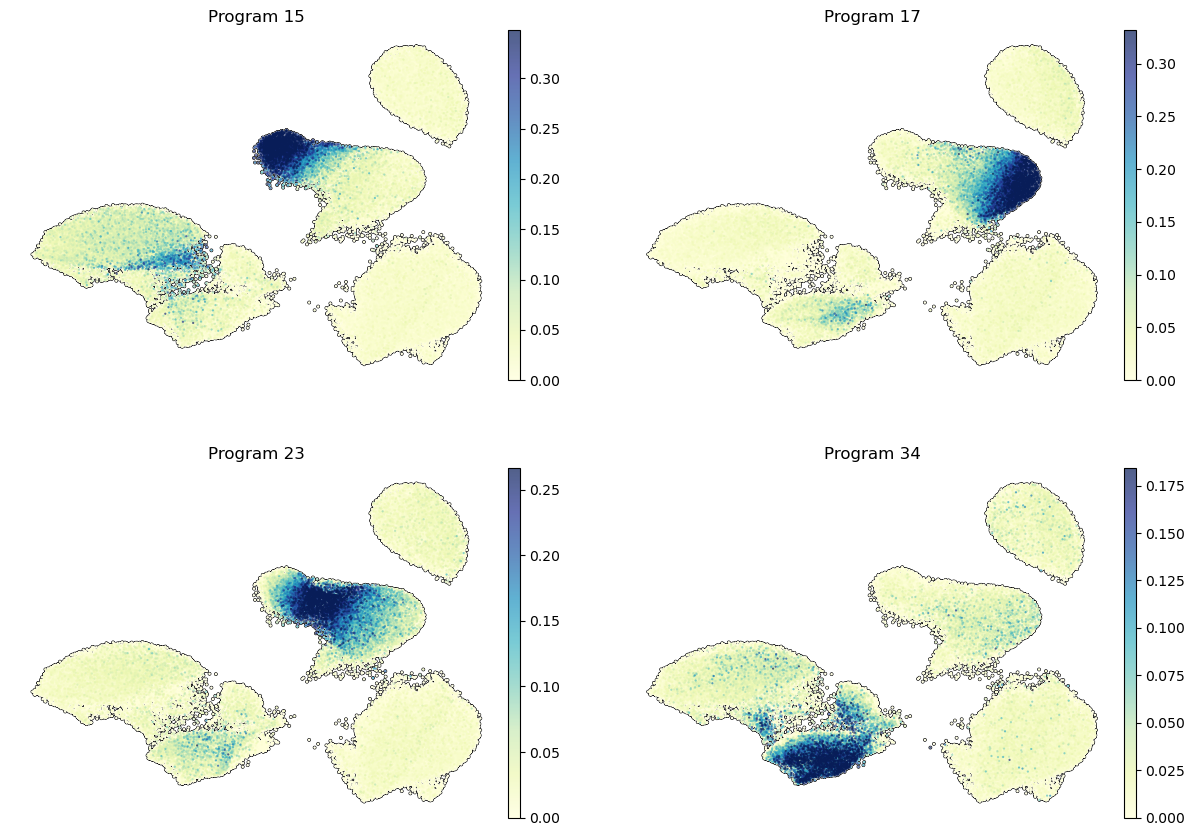

In [94]:
sc.pl.umap(adata_int, 
           color=['Program 15', 'Program 17','Program 23', 'Program 34'], 
           legend_loc='on data', 
           legend_fontsize=9, 
           add_outline=True, 
           frameon=False,
           #scale_factor=5,
           cmap="YlGnBu",
           vmin=0, vmax='p99',
           ncols=2,
           size=10)

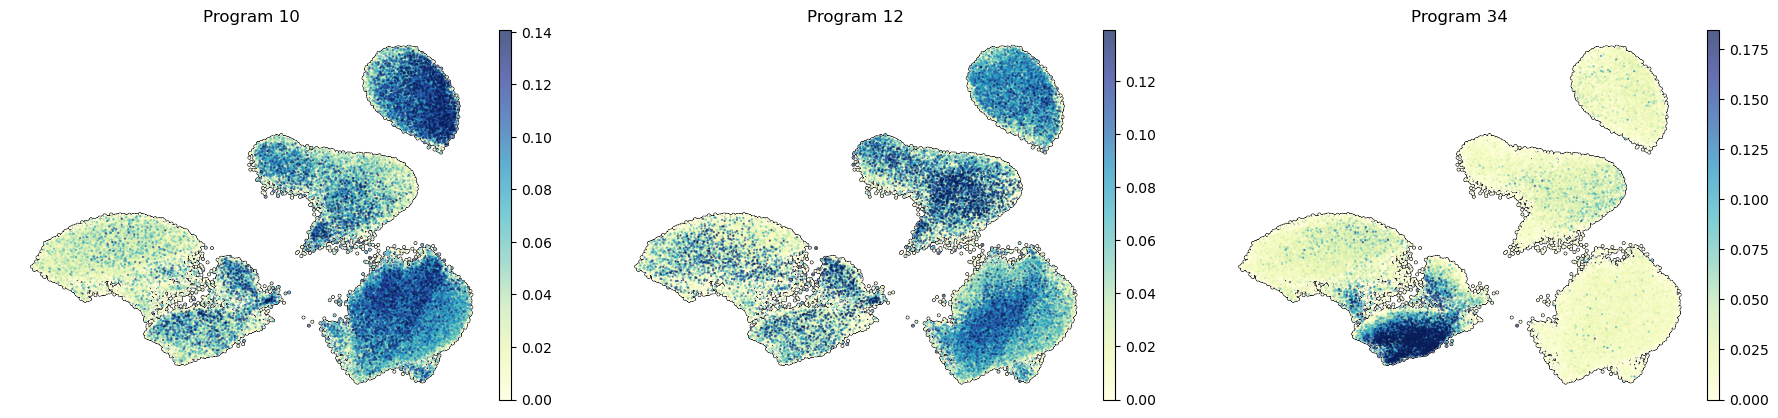

In [75]:
sc.pl.umap(adata_int, 
           color=['Program 10', 'Program 12','Program 34'], 
           legend_loc='on data', 
           legend_fontsize=9, 
           add_outline=True, 
           frameon=False,
           #scale_factor=5,
           cmap="YlGnBu",
           vmin=0, vmax='p99',
           ncols=3,
           size=10)

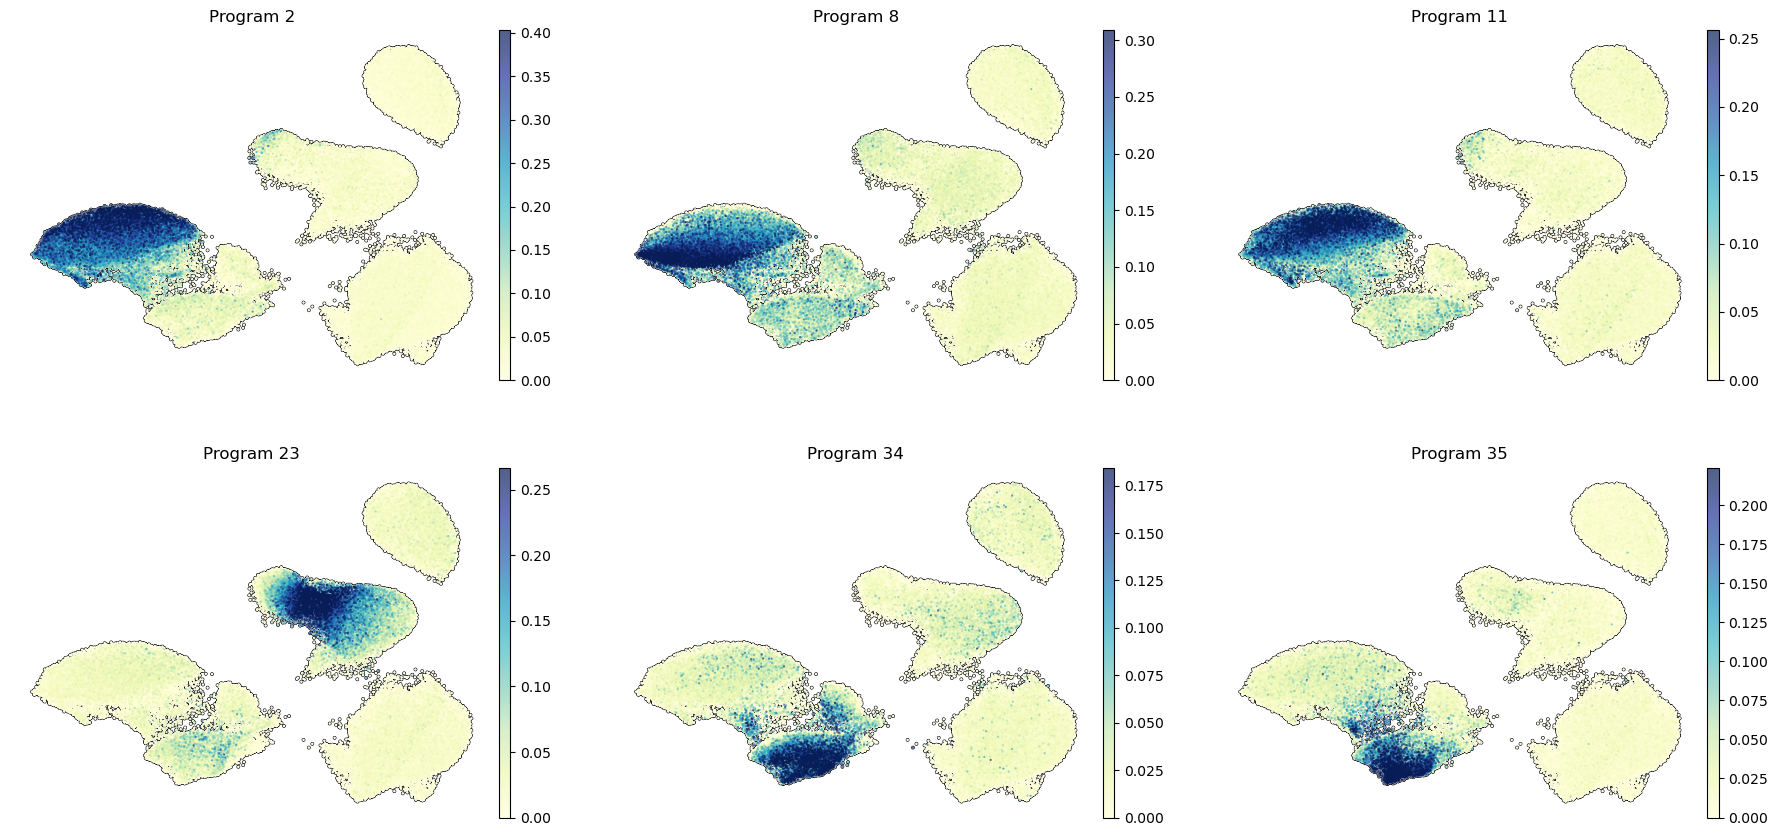

In [93]:
sc.pl.umap(adata_int, 
           color=['Program 2', 'Program 8','Program 11', 'Program 23', 'Program 34', 'Program 35'], 
           legend_loc='on data', 
           legend_fontsize=9, 
           add_outline=True, 
           frameon=False,
           #scale_factor=5,
           cmap="YlGnBu",
           vmin=0, vmax='p99',
           ncols=3,
           size=10)

Programs on UMAP

In [81]:
adata = adata_int.copy()

In [84]:
adata.obs["EC_early"] = adata.obs[["Program 15", "Program 23"]].mean(axis=1)
adata.obs["EC_late"] = adata.obs[["Program 2", "Program 8", "Program 11"]].mean(axis=1)
adata.obs["P15_minus_P17"] = adata.obs["Program 15"] - adata.obs["Program 17"]
adata.obs["ECminusP34"] = adata.obs["EC_late"] - adata.obs["Program 34"]

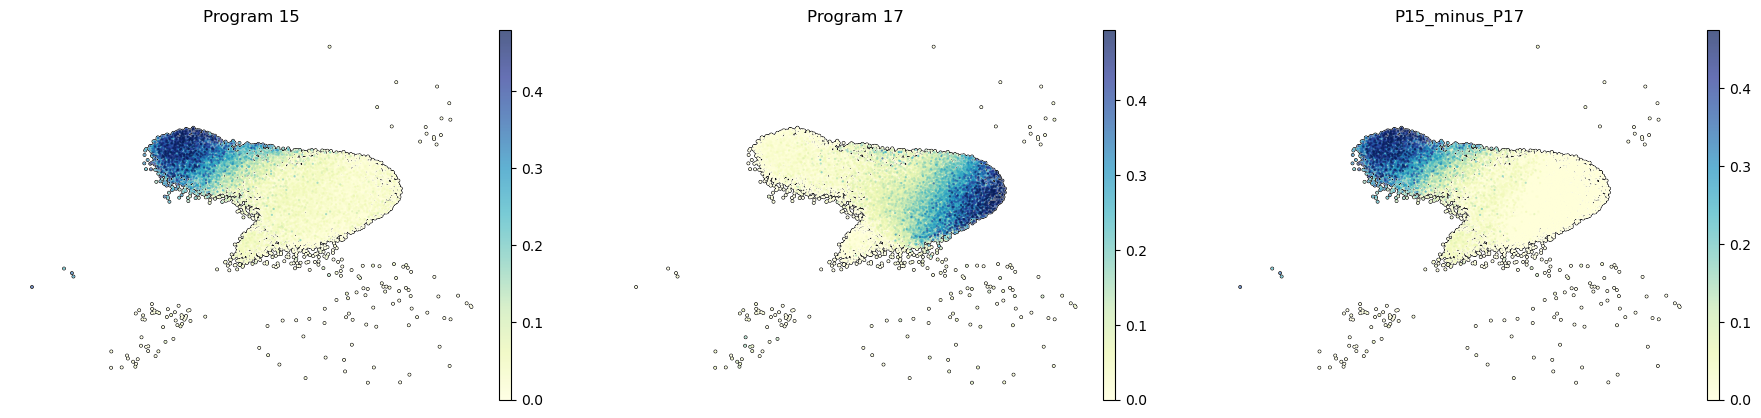

In [89]:
d2 = adata[adata.obs["day"] == "d2"].copy()

sc.pl.umap(
    d2,
    color=["Program 15", "Program 17", "P15_minus_P17"],
    legend_fontsize=9, 
    add_outline=True, 
    frameon=False,
    #scale_factor=5,
    cmap="YlGnBu",
    vmin=0, vmax='p99',
    ncols=3,
    size=10
)


In [91]:
d2_corr = d2.obs[["Program 15", "Program 17", "Program 23"]].corr()
print(d2_corr)

            Program 15  Program 17  Program 23
Program 15    1.000000   -0.361132    0.092730
Program 17   -0.361132    1.000000   -0.343786
Program 23    0.092730   -0.343786    1.000000


END POINT

In [6]:
adata_dir = "/oak/stanford/groups/engreitz/Users/ymo/IGVF_ccperturbseq/Data/raw_updated_withguide_030526.h5ad"

In [32]:
import anndata as ad
adata = ad.read_h5ad(adata_dir)

In [33]:
adata

AnnData object with n_obs × n_vars = 121616 × 17538
    obs: 'guides_per_cell', 'guide_umi_counts', 'pct_counts_ribo', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'pool', 'sample_id', 'round1', 'well', 'biological_sample', 'plate', 'bci', 'stype', 'day', 'cell_pool', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'S_score', 'G2M_score', 'phase', 'outlier', 'size_factors', 'leiden_res_0.1', 'leiden_res_0.2', 'leiden_res_0.3', 'leiden_res_0.4', 'leiden_res_0.5', 'leiden_res_0.6', 'leiden_res_0.7', 'leiden_res_0.8', 'leiden_res_0.9', 'leiden_res_1.0', 'batch'
    var: 'symbol', 'gene_id', 'gene_names'
    uns: 'guide_names', 'guide_targets'
    obsm: 'X_pca', 'X_umap', 'guide_assignment'

In [35]:
# 1. Compute Neighbors
# Increase n_neighbors (e.g., 20 or 30) for more "global" structure
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=40)

# 2. Compute UMAP
# To spread clusters out more, increase 'min_dist' (default is 0.5)
sc.tl.umap(adata, min_dist=0.5, spread=1.0)

In [44]:
# Re-run Leiden at your preferred resolution
sc.tl.leiden(adata, resolution=1.0, key_added='leiden_new')

In [45]:
adata.obs['biological_sample']

barcode
CCTAATCCAACAACCATCTATTAC_2    d0_rep1
GGTGCGAACCTCCTGAATCCGCGA_2    d0_rep2
AACTCACCATCATTCCCTGTCCCG_1    d0_rep2
TTCACGCACACTTCGAATTCATGG_2    d0_rep2
GTCTGTCAGAGCTGAACCGTTCTA_3    d0_rep2
                               ...   
AATCCGTCTCTTCACAGTTACGTA_1    d3_rep2
ATCATTCCCGACACACTCACTTTA_2    d3_rep2
AACAACCAACACAGAAGACCTTTC_1    d3_rep1
AATGTTGCATCCTGTAGGTGGAGC_1    d3_rep1
ACCACTGTGGTGCGAACGTCTAGG_1    d3_rep1
Name: biological_sample, Length: 121616, dtype: category
Categories (8, object): ['d0_rep1', 'd0_rep2', 'd1_rep1', 'd1_rep2', 'd2_rep1', 'd2_rep2', 'd3_rep1', 'd3_rep2']

In [28]:
sc.pl.umap(adata, 
           color='leiden_new', 
           legend_loc='on data', 
           legend_fontsize=9, 
           add_outline=True, 
           frameon=False, 
           size=2)

NameError: name 'adata' is not defined

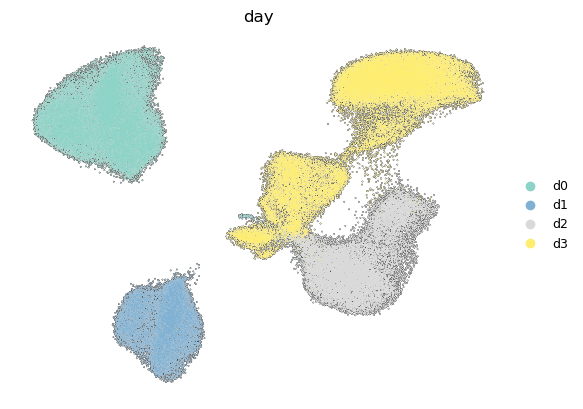

In [48]:

sc.pl.umap(adata, 
           color='day', 
           #legend_loc='on data', 
           legend_fontsize=9, 
           add_outline=True, 
           frameon=False, 
           palette='Set3',
           size=2)

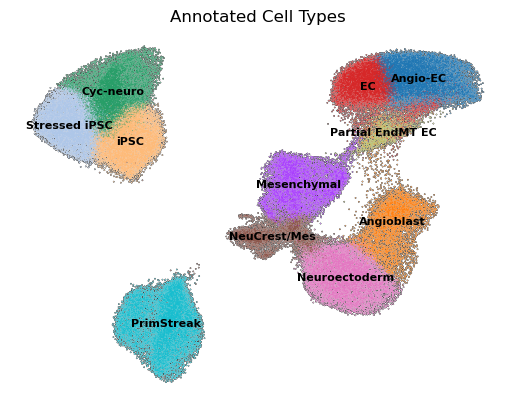

In [61]:
import scanpy as sc

# 1. Create the mapping dictionary
# Make sure the keys are strings, as cluster IDs are usually stored as categorical strings
cluster_mapping = {
    '0': 'PrimStreak',
    '1': 'Angio-EC',
    '2': 'Cyc-neuro',
    '3': 'Neuroectoderm',
    '4': 'iPSC',
    '5': 'Stressed iPSC',
    '6': 'EC',
    '7': 'Mesenchymal',
    '8': 'Angioblast',
    '9': 'NeuCrest/Mes',
    '10': 'Partial EndMT EC',
    '11': 'EC'
}

# 2. Map the labels to a new column in adata.obs
# Replace 'leiden_res_0.8' with whatever your current clustering column is named
adata.obs['cell_type'] = adata.obs['leiden_new'].astype(str).map(cluster_mapping)

# Convert the new column to a categorical type (important for Scanpy plotting colors)
adata.obs['cell_type'] = adata.obs['cell_type'].astype('category')

# 3. Plot the updated UMAP
sc.pl.umap(adata, 
           color='cell_type', 
           legend_loc='on data', 
           legend_fontsize=8, 
           #legend_fontoutline=2, # Adds the white outline we used earlier
           frameon=False,
           add_outline=True,
           size=2,
           title='Annotated Cell Types')

In [62]:
adata

AnnData object with n_obs × n_vars = 121616 × 17538
    obs: 'guides_per_cell', 'guide_umi_counts', 'pct_counts_ribo', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'pool', 'sample_id', 'round1', 'well', 'biological_sample', 'plate', 'bci', 'stype', 'day', 'cell_pool', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'S_score', 'G2M_score', 'phase', 'outlier', 'size_factors', 'leiden_res_0.1', 'leiden_res_0.2', 'leiden_res_0.3', 'leiden_res_0.4', 'leiden_res_0.5', 'leiden_res_0.6', 'leiden_res_0.7', 'leiden_res_0.8', 'leiden_res_0.9', 'leiden_res_1.0', 'batch', 'leiden_new', 'cell_type'
    var: 'symbol', 'gene_id', 'gene_names'
    uns: 'guide_names', 'guide_targets', 'neighbors', 'umap', 'leiden_new', 'leiden_new_colors', 'biological_sample_colors', 'day_colors', '

In [64]:
adata.obsm['guide_assignment']

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 646492 stored elements and shape (121616, 1922)>

In [65]:
adata.uns['guide_names']

array(['ACAA1_+_38178488.23-P1P2', 'ACAA1_+_38178517.23-P1P2',
       'ACAA1_+_38178559.23-P1P2', ..., 'non-targeting_03620',
       'non-targeting_03635', 'non-targeting_03664'],
      shape=(1922,), dtype=object)

In [69]:
import numpy as np

# 1. Create a boolean mask AND convert it to a numpy array using .values
# Make sure to update 'Mesenchymal' to whatever exact string you used (e.g., 'Mes-ECM' or 'NC/Mes')
cluster_mask = (adata.obs['cell_type'] == 'Mesenchymal').values 

# 2. Extract guide targets as a numpy array for easy searching
guide_targets = np.array(adata.uns['guide_targets'])

# 3. Define the targets you want to look for
targets_to_count = ['NF2', 'LATS2', 'AMOTL2', 'non-targeting']

print("Number of Mes-ECM cells with guides targeting:")
print("-" * 50)

# 4. Loop through each target and calculate the cells
for target in targets_to_count:
    # Find the column indices for all guides that target this specific gene
    col_indices = np.where(guide_targets == target)[0]
    
    if len(col_indices) == 0:
        print(f"{target}: 0 cells (Target name not found in adata.uns['guide_targets'])")
        continue
        
    # Slice the sparse matrix using the numpy array mask
    target_matrix = adata.obsm['guide_assignment'][cluster_mask][:, col_indices]
    
    # Sum across the columns (axis=1). If the sum is > 0, the cell has at least 
    # one guide for this target. .A1 flattens it to a standard 1D array.
    cells_with_target = (target_matrix.sum(axis=1).A1 > 0).sum()
    
    print(f"{target}: {cells_with_target} cells")

Number of Mes-ECM cells with guides targeting:
--------------------------------------------------
NF2: 488 cells
LATS2: 521 cells
AMOTL2: 389 cells
non-targeting: 2101 cells


--- Raw Cell Counts (Plotted Lineages Only) ---


,NeuCrest/Mes,Mesenchymal,Endothelial
NF2,108,488,246
LATS2,160,521,340
AMOTL2,137,389,309
non-targeting,1137,2101,4240



--- Relative Proportions (%) ---


,NeuCrest/Mes,Mesenchymal,Endothelial
NF2,12.8,58.0,29.2
LATS2,15.7,51.0,33.3
AMOTL2,16.4,46.6,37.0
non-targeting,15.2,28.1,56.7


<Figure size 800x600 with 0 Axes>

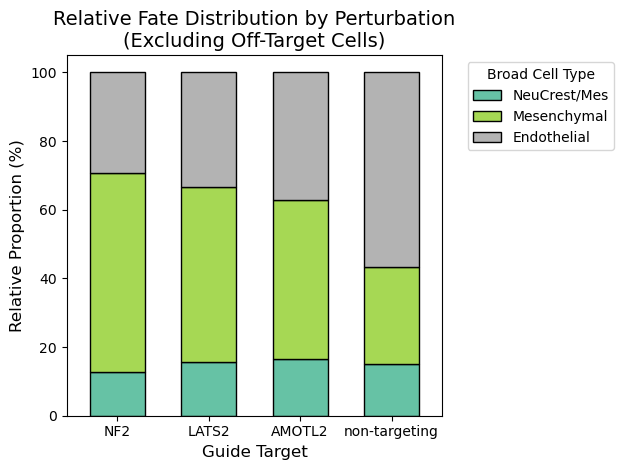

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define the targets we want to count
guide_targets = np.array(adata.uns['guide_targets'])
targets = ['NF2', 'LATS2', 'AMOTL2', 'non-targeting']

# 2. Define boolean masks for our 3 broad cell types
masks = {
    'NeuCrest/Mes': (adata.obs['cell_type'] == 'NeuCrest/Mes').values,
    'Mesenchymal': (adata.obs['cell_type'] == 'Mesenchymal').values,
    'Endothelial': (adata.obs['cell_type'].isin(['Angio-EC', 'EC', 'Partial EndMT EC'])).values
}

# 3. Initialize a dictionary to store counts
counts = {cell_type: [] for cell_type in masks.keys()}

# 4. Loop through each target and count
for target in targets:
    col_indices = np.where(guide_targets == target)[0]
    
    if len(col_indices) == 0:
        for ct in masks.keys(): counts[ct].append(0)
        continue
        
    # Count cells specifically in the 3 broad cell types
    for cell_type, mask in masks.items():
        target_matrix = adata.obsm['guide_assignment'][mask][:, col_indices]
        cells_with_target = (target_matrix.sum(axis=1).A1 > 0).sum()
        counts[cell_type].append(cells_with_target)

# 5. Compile the results into a DataFrame
df_counts = pd.DataFrame(counts, index=targets)

# 6. Convert counts to relative proportions (percentages)
# We divide by the sum of just these 3 columns so the bars total 100%
total_plotted_cells = df_counts.sum(axis=1)
df_pct = df_counts.div(total_plotted_cells, axis=0) * 100

# Print the numerical results to the console
print("--- Raw Cell Counts (Plotted Lineages Only) ---")
display(df_counts)
print("\n--- Relative Proportions (%) ---")
display(df_pct.round(1))

# 7. Plotting the Stacked Bar Chart
plt.figure(figsize=(8, 6))

ax = df_pct.plot(kind='bar', stacked=True, colormap='Set2', edgecolor='black', width=0.6)

# Formatting the plot
plt.title('Relative Fate Distribution by Perturbation on Day 3)', fontsize=14)
plt.ylabel('Relative Proportion (%)', fontsize=12)
plt.xlabel('Guide Target', fontsize=12)
plt.xticks(rotation=0)

# Move the legend outside the plot area
plt.legend(title='Broad Cell Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('guide_fate_proportions_no_other.pdf', bbox_inches='tight')
plt.show()

<Figure size 800x600 with 0 Axes>

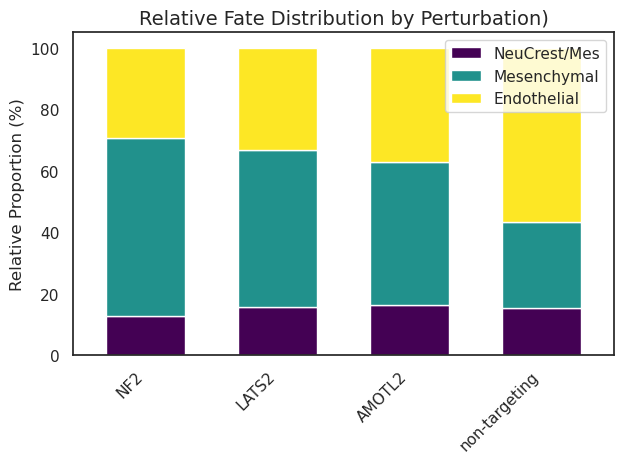

In [76]:
# 7. Plotting the Stacked Bar Chart
plt.figure(figsize=(8, 6))

ax = df_pct.plot(kind='bar', stacked=True, colormap='viridis', edgecolor='white', width=0.6)

# Formatting the plot
plt.title('Relative Fate Distribution by Perturbation)', fontsize=14)
plt.ylabel('Relative Proportion (%)', fontsize=12)

# UPDATE THIS LINE:
plt.xticks(rotation=45, ha='right')

# Move the legend outside the plot area
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout so the rotated labels don't get cut off when saving
plt.tight_layout()
plt.savefig('guide_fate_proportions_45deg.pdf', bbox_inches='tight')
plt.show()

--- Raw Cell Counts (Plotted Lineages Only) ---


,NeuCrest/Mes,Mesenchymal,Endothelial
SMAD1,837,227,492
non-targeting,1137,2101,4240



--- Relative Proportions (%) ---


,NeuCrest/Mes,Mesenchymal,Endothelial
SMAD1,53.8,14.6,31.6
non-targeting,15.2,28.1,56.7


<Figure size 600x600 with 0 Axes>

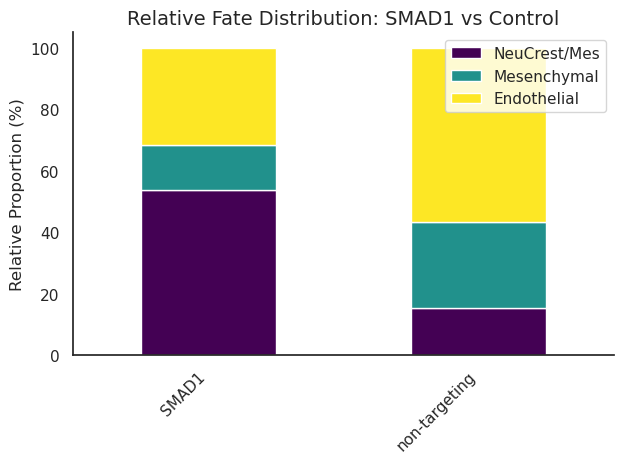

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the targets we want to compare
guide_targets = np.array(adata.uns['guide_targets'])
targets = ['SMAD1', 'non-targeting']

# 2. Define boolean masks for our 3 broad cell types
masks = {
    'NeuCrest/Mes': (adata.obs['cell_type'] == 'NeuCrest/Mes').values,
    'Mesenchymal': (adata.obs['cell_type'] == 'Mesenchymal').values,
    'Endothelial': (adata.obs['cell_type'].isin(['Angio-EC', 'EC', 'Partial EndMT EC'])).values
}

# 3. Initialize a dictionary to store counts
counts = {cell_type: [] for cell_type in masks.keys()}

# 4. Loop through each target and count
for target in targets:
    col_indices = np.where(guide_targets == target)[0]
    
    if len(col_indices) == 0:
        for ct in masks.keys(): counts[ct].append(0)
        continue
        
    # Count cells specifically in the 3 broad cell types
    for cell_type, mask in masks.items():
        target_matrix = adata.obsm['guide_assignment'][mask][:, col_indices]
        cells_with_target = (target_matrix.sum(axis=1).A1 > 0).sum()
        counts[cell_type].append(cells_with_target)

# 5. Compile the results into a DataFrame
df_counts = pd.DataFrame(counts, index=targets)

# 6. Convert counts to relative proportions (percentages)
total_plotted_cells = df_counts.sum(axis=1)
df_pct = df_counts.div(total_plotted_cells, axis=0) * 100

# Print the numerical results to the console
print("--- Raw Cell Counts (Plotted Lineages Only) ---")
display(df_counts)
print("\n--- Relative Proportions (%) ---")
display(df_pct.round(1))

# 7. Plotting the Stacked Bar Chart
sns.set_theme(style="white") # Clean background

plt.figure(figsize=(6, 6)) # Slightly narrower since we only have 2 bars now

ax = df_pct.plot(kind='bar', 
                 stacked=True, 
                 colormap='viridis', 
                 edgecolor='white', 
                 linewidth=1,
                 width=0.5) # Thinner bars look better when there are fewer of them

# Formatting the plot
plt.title('Relative Fate Distribution: SMAD1 vs Control', fontsize=14)
plt.ylabel('Relative Proportion (%)', fontsize=12)
#plt.xlabel('Guide Target', fontsize=12)

# Rotated labels for readability
plt.xticks(rotation=45, ha='right')

# Move the legend outside the plot area
#plt.legend(title='Broad Cell Type', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()

plt.tight_layout()
plt.savefig('smad1_vs_control_fate.pdf', bbox_inches='tight')
plt.show()

END POINT

In [5]:
data_dir = "/oak/stanford/groups/engreitz/Users/opushkar/cc_perturb/2.preprocessing_tonys_pipeline/2.normalized_data/normalized_data"
working_dir = "/oak/stanford/groups/engreitz/Users/tri/CodeBase/programDE/notebooks"

In [6]:
mdata = mu.read(f"{data_dir}/d1_normalized_gex_and_guide.h5mu")

/oak/stanford/groups/engreitz/Users/tri/envs/sc-dl/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/oak/stanford/groups/engreitz/Users/tri/envs/sc-dl/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [7]:
adata = mdata['GEX'].copy()

#### Import cNMF matrix

In [8]:
# 1. Define the file path
cnmf_file = "/oak/stanford/groups/engreitz/Users/ymo/IGVF_ccperturbseq/Result/012326_100k_cells_20iter_torch_halsvar_batch_e7_v100s/012326_100k_cells_20iter_torch_halsvar_batch_e7_v100s.usages.k_50.dt_2_0.consensus.txt"

# 2. Read the dataframe
usage_df = pd.read_csv(cnmf_file, sep='\t', index_col=0)

# 3. Align with adata
# This ensures every cell in adata gets its corresponding row from the file.
# Cells in adata but missing from the file will be filled with 0 
usage_aligned = usage_df.reindex(adata.obs_names).fillna(0)

# 4. Save to obsm
adata.obsm["cnmf_usage"] = usage_aligned

# 5. Validation
print(f"Loaded usage matrix shape: {adata.obsm['cnmf_usage'].shape}")
print(f"Overlap check: {usage_df.index.intersection(adata.obs_names).shape[0]} cells matched.")

Loaded usage matrix shape: (16925, 50)
Overlap check: 16925 cells matched.


In [9]:
# Guide names must match columns of guide_assignment
guide_names = list(mdata["guide"].var_names)
adata.uns["guide_names"] = guide_names

In [10]:
# Program names
adata.uns["program_names"] = list(adata.obsm["cnmf_usage"].columns)

#### Import guide assignment

In [11]:
guide_file = "/oak/stanford/groups/engreitz/Users/tri/CodeBase/programDE/notebooks/d1_sceptre_transfer/d1_grna_assignments_long.csv"

# 1. Read
df_long = pd.read_csv(guide_file)

# 2. Pivot
# aggfunc='max' ensures that if a (cell, guide) pair is listed twice, we just keep 1.
guide_dense = df_long.pivot_table(
    index='cell_id', 
    columns='grna_target', 
    values='value', 
    fill_value=0,
    aggfunc='max' 
)

# 3. Align with adata
# This ensures strict ordering matching your AnnData
guide_aligned = guide_dense.reindex(adata.obs_names, fill_value=0)

# 4. Save
adata.obsm["guide_assignment"] = guide_aligned.astype(np.int8)

print(f"✅ Loaded guide assignment: {adata.obsm['guide_assignment'].shape}")

✅ Loaded guide assignment: (16925, 1918)


#### Map guide to gene using guide name/ID

In [12]:
# guide2gene: map guide_name -> gene by taking the first token of guide_name.split('_')
guide2gene = {gn: gn.split("_", 1)[0] for gn in guide_names}
adata.uns["guide2gene"] = guide2gene

In [13]:
adata

AnnData object with n_obs × n_vars = 16925 × 13383
    obs: 'guides_per_cell', 'guide_umi_counts', 'pct_counts_ribo', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'pool', 'sample_id', 'round1', 'well', 'biological_sample', 'plate', 'bci', 'stype', 'day', 'cell_pool', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'S_score', 'G2M_score', 'phase', 'outlier', 'size_factors', 'leiden_res_0.1', 'leiden_res_0.2', 'leiden_res_0.3', 'leiden_res_0.4', 'leiden_res_0.5', 'leiden_res_0.6', 'leiden_res_0.7', 'leiden_res_0.8', 'leiden_res_0.9', 'leiden_res_1.0'
    var: 'gene_id', 'symbol', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'n_counts', 'highly_deviant', 'highly_deviant

#### Define covariates

In [14]:
# Covariates

#(~ log(response_n_nonzero) + log(response_n_umis) +
#         log(grna_n_nonzero) + log(grna_n_umis) + response_p_mito + batch)

covariates_df = pd.DataFrame({
    #"batch": adata.obs['sample_id'],
    "grna_n_nonzero": np.log1p(adata.obs['guides_per_cell']),
    #"grna_n_umis": np.log1p(adata.obs['guide_umi_counts']),
    #"response_n_nonzero": np.log1p(adata.obs['n_genes_by_counts']),
    "response_n_umis": np.log1p(adata.obs['total_counts']),
    "response_p_mito": adata.obs['pct_counts_mt'],
})

In [26]:
adata

AnnData object with n_obs × n_vars = 16925 × 13383
    obs: 'guides_per_cell', 'guide_umi_counts', 'pct_counts_ribo', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'pool', 'sample_id', 'round1', 'well', 'biological_sample', 'plate', 'bci', 'stype', 'day', 'cell_pool', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'S_score', 'G2M_score', 'phase', 'outlier', 'size_factors', 'leiden_res_0.1', 'leiden_res_0.2', 'leiden_res_0.3', 'leiden_res_0.4', 'leiden_res_0.5', 'leiden_res_0.6', 'leiden_res_0.7', 'leiden_res_0.8', 'leiden_res_0.9', 'leiden_res_1.0'
    var: 'gene_id', 'symbol', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'n_counts', 'highly_deviant', 'highly_deviant

In [15]:
adata.obsm["covar"] = covariates_df

In [16]:
adata.obsm["covar"]

,grna_n_nonzero,response_n_umis,response_p_mito
barcode,,,
AACGTGATGTGTTCTATACGGTTA_2,1.386294,7.971948,12.067884
CCATCCTCCAACCACATTGGGAGA_3,2.397895,7.941189,18.792038
AGTACAAGGCGAGTAATTATTCTG_1,1.945910,7.983145,15.733069
GTACGCAAACCACTGTTACGGTTA_2,2.079442,6.581697,24.765429
ACAGATTCCCGACAACTACGGTTA_1,1.945910,7.288569,18.803732
...,...,...,...
AAACATCGCATACCAATTGTCTTA_2,1.098612,7.895391,9.948281
CATCAAGTACTATGCATTGTCTTA_3,2.564949,9.038201,8.529727
CACCTTACGCTCGGTATTATTCTG_1,0.000000,8.173619,9.999566


#### Flooring and Renormalizing cNMF matrix

In [17]:
U = adata.obsm["cnmf_usage"]
print("min:", U.min(), "quantile:", np.quantile(U, 1e-4))
print("row sums == 0:", np.sum(U.sum(axis=1) == 0))

min: 1     0.0
2     0.0
3     0.0
4     0.0
5     0.0
6     0.0
7     0.0
8     0.0
9     0.0
10    0.0
11    0.0
12    0.0
13    0.0
14    0.0
15    0.0
16    0.0
17    0.0
18    0.0
19    0.0
20    0.0
21    0.0
22    0.0
23    0.0
24    0.0
25    0.0
26    0.0
27    0.0
28    0.0
29    0.0
30    0.0
31    0.0
32    0.0
33    0.0
34    0.0
35    0.0
36    0.0
37    0.0
38    0.0
39    0.0
40    0.0
41    0.0
42    0.0
43    0.0
44    0.0
45    0.0
46    0.0
47    0.0
48    0.0
49    0.0
50    0.0
dtype: float64 quantile: 0.0
row sums == 0: 0


In [18]:
U0 = adata.obsm["cnmf_usage"]
pos = U0[U0 > 0]
eps = max(1e-8, np.quantile(pos, 0.01) * 0.1)  # e.g. 10% of 1% quantile
Uf = np.where(U0 > 0, U0, eps)
Uf = Uf / Uf.sum(axis=1, keepdims=True)
adata.obsm["cnmf_usage"] = Uf

#### Prepare input for programDE pipeline 

In [19]:

inputs = prepare_crt_inputs(
    adata=adata,
    usage_key="cnmf_usage",
    covar_key="covar",
    guide_assignment_key="guide_assignment",
    guide2gene_key="guide2gene"
)

In [20]:
from src.sceptre import (
    build_ntc_group_inputs,
    compute_ntc_group_null_pvals_parallel,
    crt_pvals_for_ntc_groups_ensemble,
    crt_pvals_for_ntc_groups_ensemble_skew,
    make_ntc_groups_ensemble,
    run_all_genes_union_crt,
)
from src.visualization import qq_plot_ntc_pvals

In [21]:
import os
cpus_per_task = int(os.environ.get("SLURM_CPUS_PER_TASK", 1))

In [22]:
cpus_per_task

4

### CRT without stratification

In [23]:

out = run_all_genes_union_crt(
    inputs=inputs,
    B=1023,
    n_jobs=cpus_per_task,
    calibrate_skew_normal=True,
    return_raw_pvals=True,
    return_skew_normal=True,
)


KeyboardInterrupt: 

In [ ]:
ntc_labels = ["SAFE","non-targeting"]
# Identify NTC guides and build guide-frequency bins / real-gene signatures
ntc_guides, guide_freq, guide_to_bin, real_sigs = build_ntc_group_inputs(
    inputs=inputs,
    ntc_label=ntc_labels,
    group_size=6,
    n_bins=10,
)

In [ ]:

# Create multiple random partitions (ensembles) of NTC guides into 6-guide groups
ntc_groups_ens = make_ntc_groups_ensemble(
    ntc_guides=ntc_guides,
    ntc_freq=guide_freq,
    real_gene_bin_sigs=real_sigs,
    guide_to_bin=guide_to_bin,
    n_ensemble=10,
    seed0=7,
    group_size=6,
    max_groups=None,
)
# Compute raw CRT p-values for each NTC group in each ensemble
ntc_group_pvals_ens = crt_pvals_for_ntc_groups_ensemble(
    inputs=inputs,
    ntc_groups_ens=ntc_groups_ens,
    B=1023,
    seed0=23,
)
# Compute skew-calibrated CRT p-values for each NTC group in each ensemble
ntc_group_pvals_skew_ens = crt_pvals_for_ntc_groups_ensemble_skew(
    inputs=inputs,
    ntc_groups_ens=ntc_groups_ens,
    B=1023,
    seed0=23,
) 

In [ ]:
# Build CRT-null p-values matched to NTC group units (recommended)
null_pvals = compute_ntc_group_null_pvals_parallel(
    inputs=inputs,
    ntc_groups_ens=ntc_groups_ens,
    B=1023,
    n_jobs=cpus_per_task,
    backend="threading",
)

/oak/stanford/groups/engreitz/Users/tri/envs/sc-dl/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


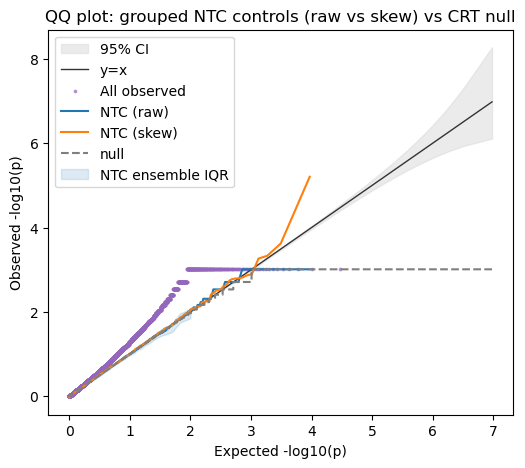

In [ ]:
ax = qq_plot_ntc_pvals(
    pvals_raw_df=out["pvals_raw_df"],
    guide2gene=adata.uns["guide2gene"],
    ntc_genes=ntc_labels,
    pvals_skew_df=out["pvals_df"],
    null_pvals=null_pvals,
    ntc_group_pvals_ens=ntc_group_pvals_ens,
    ntc_group_pvals_skew_ens=ntc_group_pvals_skew_ens,
    show_ntc_ensemble_band=True,
    show_all_pvals=True,
    title="QQ plot: grouped NTC controls (raw vs skew) vs CRT null",
)

import matplotlib.pyplot as plt
plt.show()